# ACF Analysis — pRS038 / pRS048


In [1]:
from pathlib import Path
import numpy as np
current_dir = Path().resolve()
from microlive.imports import *
from microlive import microscopy as mi
from pipeline_time_courses import (
    compute_autocorrelation_for_dataset,
    compute_cross_correlation_for_dataset,
    analyze_crosscorr,
    analyze_dual_channel_time_courses,
    run_simulation_and_generate_data,
    plot_dual_channel_kymograph,
)

In [ ]:


data_folder_sf = Path('/Volumes/Luis_DRIVE/CoF Manuscript LIFs/Processing_ACF_files/processing_GFPsf')
data_folder_uv = Path('/Volumes/Luis_DRIVE/CoF Manuscript LIFs/Processing_ACF_files/processing_GFPuv')
data_folder_end_xbp1 = Path('/Volumes/Luis_DRIVE/CoF Manuscript LIFs/Fig 4_fast Xbp1u ACF LIF Files/results_pRS038')
data_folder_start_xbp1 = Path('/Volumes/Luis_DRIVE/CoF Manuscript LIFs/Fig 4_fast Xbp1u ACF LIF Files/results_pRS048')

list_datasets = [data_folder_sf,  data_folder_uv, data_folder_end_xbp1, data_folder_start_xbp1]
list_names = [sfGFP, GFPuv, GFP_end_xbp1, GFP_start_xbp1]

In [ ]:
# ============================================================
# 🔧 PARAMETERS — edit here to control the analysis
# ============================================================

# --- Paths ---
data_folder = Path('/Volumes/Luis_DRIVE/CoF Manuscript LIFs/Fig 4_fast Xbp1u ACF LIF Files/results_pRS038')
#data_folder = Path('/Volumes/Luis_DRIVE/CoF Manuscript LIFs/Fig 4_fast Xbp1u ACF LIF Files/results_pRS048')
#data_folder = Path('/Volumes/Luis_DRIVE/CoF Manuscript LIFs/Processing_ACF_files/processing_GFPsf')
#data_folder = Path('/Volumes/Luis_DRIVE/CoF Manuscript LIFs/Processing_ACF_files/processing_GFPuv')



# data_folder = Path('/Users/nzlab-la/Desktop/processing_GFPsf')
# data_folder = Path('/Users/nzlab-la/Desktop/processing_GFPuv')
results_folder = data_folder / 'processing'
results_folder.mkdir(exist_ok=True)
plot_name = data_folder.name + '_ACF.svg'

# --- Dataset identifier ---
dataset_name = 'cof'

# --- Acquisition ---
step_size_in_sec = 5      # seconds per frame
gene_length = 1826        # codons — used for kinetics calculation

# --- Quality filtering ---
min_snr = 0.5
min_percentage_data_in_trajectory = 0.25
max_missing_frames = 3
smooth_window = 1

# --- ACF settings ---
selected_field = 'spot_int_ch_'
start_lag = 1
max_lag = 359
x_axes_min_max_list_values = [-10, 500]
y_axes_min_max_list_values = [-0.02, 0.04]
remove_outliers = True
MAD_THRESHOLD_FACTOR = 6
use_global_mean = False
correct_baseline = True
downsample = False
downsampling_factor = 3
control_spots_mode = False

# --- Multi-tau ---

multi_tau = True
multi_tau_raw_points = 40
multi_tau_bins_per_stage = 20

# --- ACF baseline ---
baseline_method = 'auto_plateau'   # 'auto_plateau' | 'exp_tail' | 'percentile' | 'none'
baseline_plateau_fraction = 0.5
baseline_percentile = 30.0
baseline_smooth_window = 5
baseline_min_points = 20
baseline_weight_by_pairs = True

# --- Plot colors ---
line_color = color_magenta     # from microlive.imports
line_color_fit = 'dimgray'

# --- Kymograph ---
primary_channel = 1     # HA-TAG (appears first)
secondary_channel = 0   # GFP-TAG (appears second)
max_traces_to_plot = 190

# --- ACF fit & save ---
fit_type = 'exponential'               # 'exponential' | 'linear'
de_correlation_threshold = 0.002
use_linear_projection_for_lag_0 = True
save_plots = False
index_max_lag_for_fit_ch1 = None       # None = auto; or integer to fix fit range
index_max_lag_for_fit_ch0 = 40         # GFP channel often needs a fixed fit range

# --- Simulation (set to True to use TASEP model instead of data) ---
simulation_mode = False

detrend = True

if control_spots_mode:
    y_axes_min_max_list_values = None

In [10]:
# Load simulated data — only runs when simulation_mode=True
if simulation_mode:
    gene_sequence_path = current_dir.parents[1].joinpath(
        'data', 'gene_sequences',
        'pRS027 (pUB-RBsmHA-4xsfGFPq-2xmCherryq-24xMS2).dna'
    )
    SSA_HA, SSA_GFP = run_simulation_and_generate_data(
        gene_sequence_path, ki=0.08, ke_global=6,
        step_size_in_sec=step_size_in_sec, folding_delay=7, t_max=360*5,
    )
else:
    SSA_HA, SSA_GFP = None, None

## Kymograph


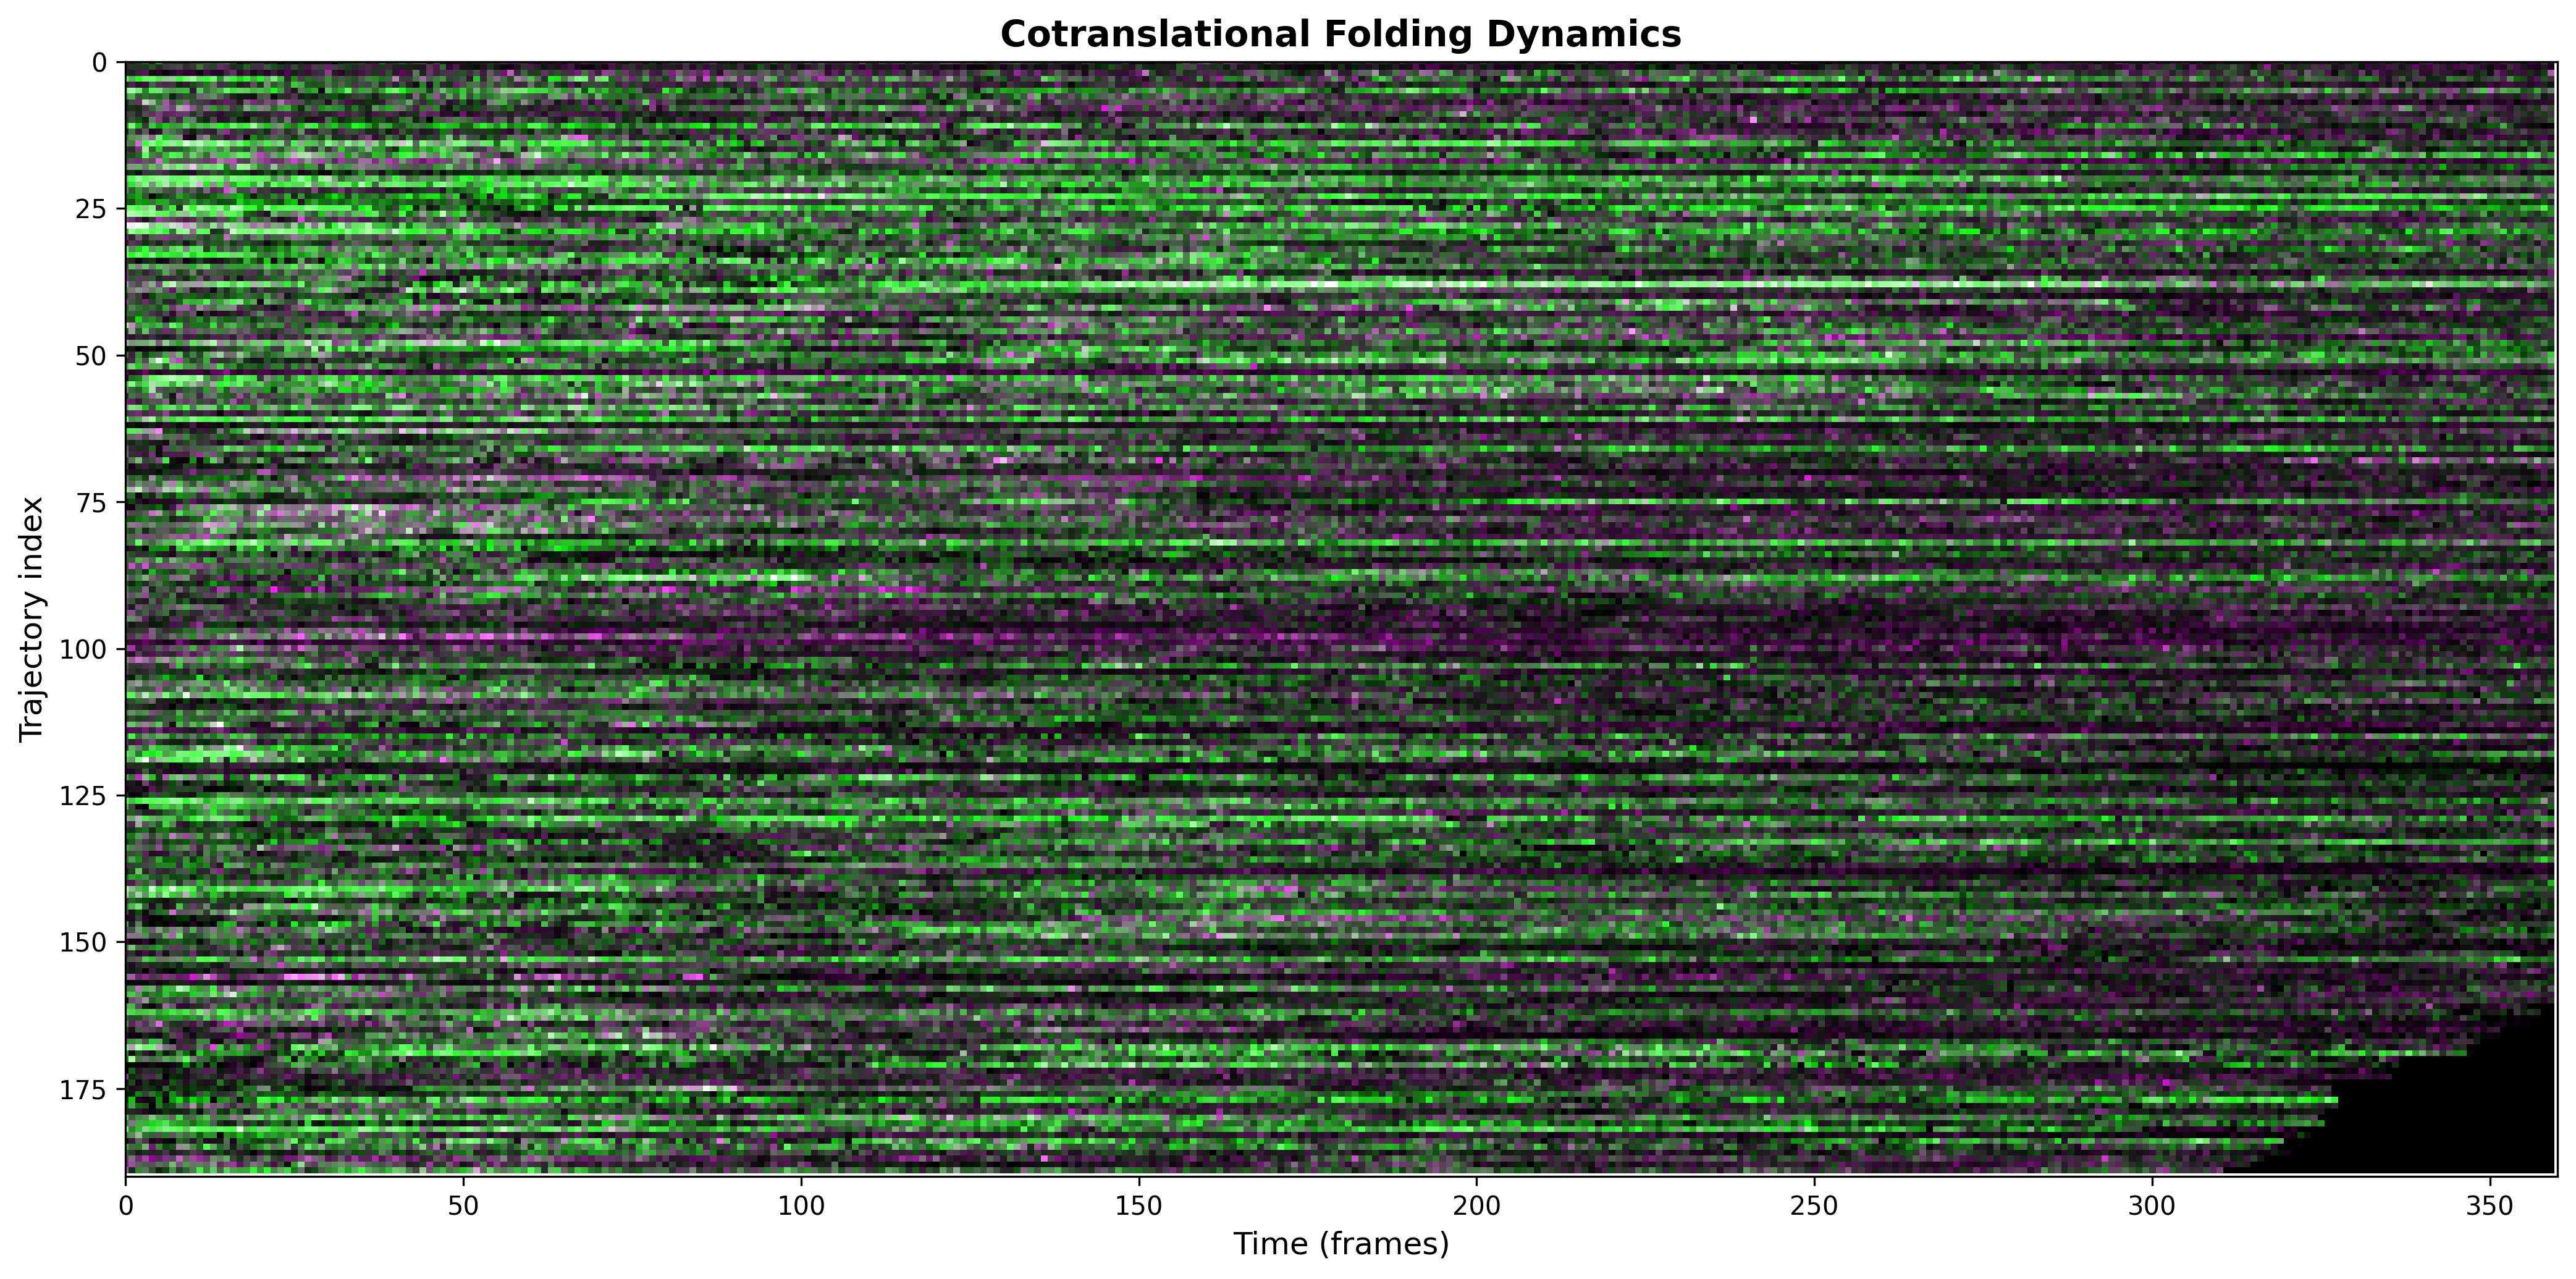

In [11]:
if simulation_mode:
    img, primary, secondary = plot_dual_channel_kymograph(
        dataset=dataset_name,
        selected_field='snr_ch_',
        primary_channel=primary_channel,
        secondary_channel=secondary_channel,
        normalize='per_trace_percentile',
        p_lo=1, p_hi=99,
        sort_by_data_density=True,
        nan_color=(0.0, 0.0, 0.0),
        title='Simulated Cotranslational Folding Dynamics',
        figsize=(12, 12), dpi=300,
        show=True, verbose=False,
        simulation_mode=True,
        SSA_data_1=SSA_HA / np.max(SSA_HA),
        SSA_data_2=SSA_GFP / np.max(SSA_GFP),
        shift_data=True,
        use_binarization=True,
        binarization_threshold=0.5,
        channel_colors=['r', 'g'],
    )
else:
    img_exp, primary_exp, secondary_exp = plot_dual_channel_kymograph(
        dataset=dataset_name,
        data_folder=data_folder,
        results_folder=results_folder,
        selected_field='snr_ch_',
        primary_channel=primary_channel,
        secondary_channel=secondary_channel,
        min_percentage_data_in_trajectory=min_percentage_data_in_trajectory,
        max_missing_frames=max_missing_frames,
        min_snr=0,
        smooth_window=smooth_window,
        normalize=None,
        p_lo=1, p_hi=99,
        sort_by_data_density=True,
        nan_color=(0.0, 0.0, 0.0),
        title='Cotranslational Folding Dynamics',
        figsize=(14, 7), dpi=300,
        channel_colors=[color_magenta, color_green],
        show=True, verbose=False,
        simulation_mode=False,
        shift_data=True,
        use_binarization=False,
        binarization_threshold=0.3,
        max_traces_to_plot=max_traces_to_plot,
    )

## Autocorrelation — Channel 1 (HA-TAG)


Fitted G(0): 0.026433352175209143


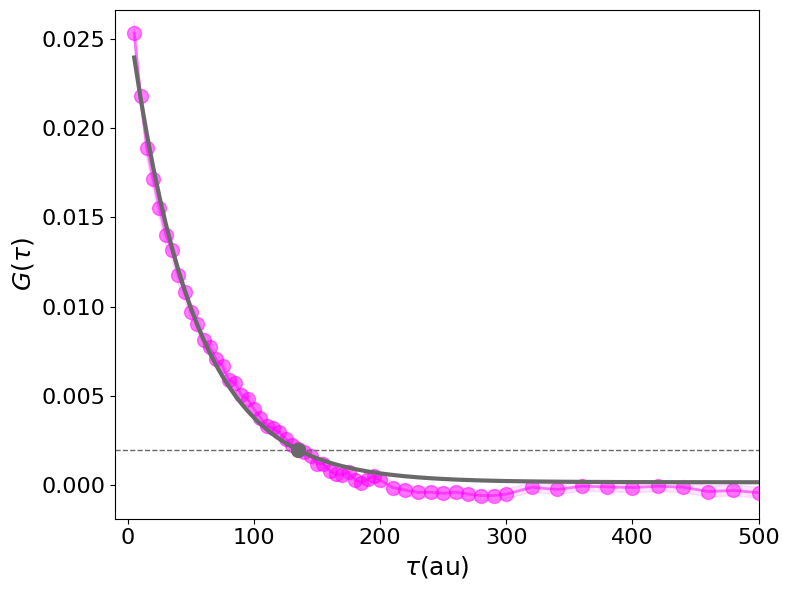

Number of trajectories: 603
Number of cells: 15


In [12]:
results_ch1 = compute_autocorrelation_for_dataset(
    dataset=dataset_name,
    data_folder=data_folder,
    results_folder=results_folder,
    selected_field=selected_field,
    channel_index=1,
    step_size_in_sec=step_size_in_sec,
    start_lag=start_lag,
    min_percentage_data_in_trajectory=min_percentage_data_in_trajectory,
    max_missing_frames=max_missing_frames,
    downsample=downsample,
    downsampling_factor=downsampling_factor,
    use_global_mean=use_global_mean,
    control_spots_mode=control_spots_mode,
    correct_baseline=correct_baseline,
    min_snr=min_snr,
    smooth_window=smooth_window,
    remove_outliers=remove_outliers,
    MAD_THRESHOLD_FACTOR=MAD_THRESHOLD_FACTOR,
    multi_tau=multi_tau,
    multi_tau_raw_points=multi_tau_raw_points,
    multi_tau_bins_per_stage=multi_tau_bins_per_stage,
    x_axes_min_max_list_values=x_axes_min_max_list_values,
    max_lag=max_lag,
    index_max_lag_for_fit=index_max_lag_for_fit_ch1,
    fit_type=fit_type,
    de_correlation_threshold=de_correlation_threshold,
    use_linear_projection_for_lag_0=use_linear_projection_for_lag_0,
    detrend=detrend,
    verbose=False,
    simulation_mode=simulation_mode,
    SSA_data=SSA_HA,
    baseline_method=baseline_method,
    baseline_plateau_fraction=baseline_plateau_fraction,
    baseline_percentile=baseline_percentile,
    baseline_smooth_window=baseline_smooth_window,
    baseline_min_points=baseline_min_points,
    baseline_weight_by_pairs=baseline_weight_by_pairs,
    line_color=line_color,
    line_color_fit=line_color_fit,
    plot_name=plot_name,
    save_plots=save_plots,
)

In [13]:
results_ch1['mean_correlation'][1]

0.02531896475720134

### Kinetics from ACF (Channel 1)


In [14]:
def calculate_ribosomal_density(ki, ke, ribosomal_footprint=10):
    return np.round((ki * ribosomal_footprint / ke) * 100, 3)

def calculate_number_ribosomes_RNA(ki, ke, gene_length):
    return np.round((ki * gene_length) / ke, 3)

def calculate_ribosomal_distance(gene_length, number_ribosomes):
    return np.round(gene_length / number_ribosomes, 3)

dwell_time = results_ch1['dwell_time']
correlation_at_lag_1 = results_ch1['mean_correlation'][1]
ke = gene_length / dwell_time
ki = 1 / (correlation_at_lag_1 * dwell_time)

ribosomal_density = calculate_ribosomal_density(ki, ke)
number_ribosomes = calculate_number_ribosomes_RNA(ki, ke, gene_length)
ribosomal_distance = calculate_ribosomal_distance(gene_length, number_ribosomes)

print(f"Data: {data_folder.stem:<20} ki: {np.round(ki,4):<8} ke: {np.round(ke,4):<8} "
      f"length: {gene_length:<5} rib_density: {ribosomal_density:<8} "
      f"no_rib: {number_ribosomes:<8} rib_dist: {ribosomal_distance:<8}")

Data: results_pRS038       ki: 0.2926   ke: 13.5259  length: 1826  rib_density: 21.63    no_rib: 39.496   rib_dist: 46.233  


## Autocorrelation — Channel 0 (GFP-TAG)


Fitted G(0): 0.04460041860190572
Could not find a time where G(τ) falls below threshold.


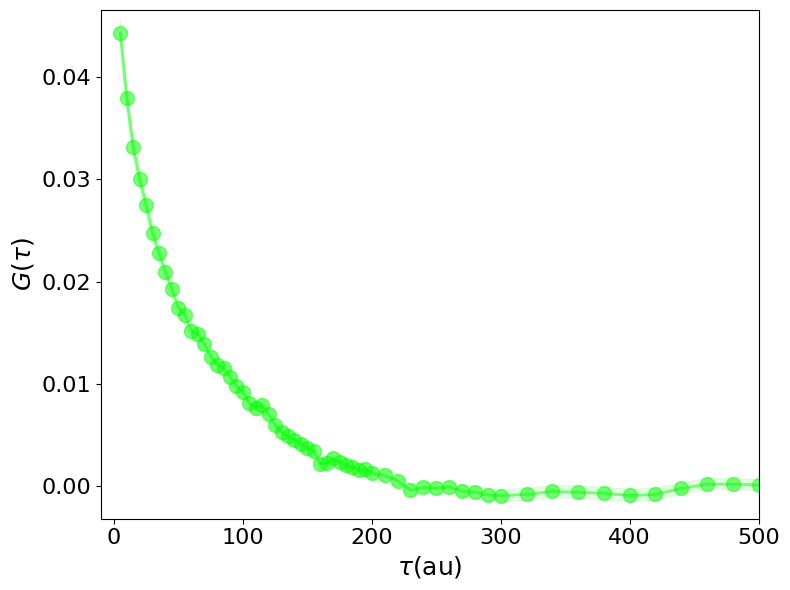

Number of trajectories: 594
Number of cells: 15


In [15]:
results_ch0 = compute_autocorrelation_for_dataset(
    dataset=dataset_name,
    data_folder=data_folder,
    results_folder=results_folder,
    selected_field=selected_field,
    channel_index=0,
    step_size_in_sec=step_size_in_sec,
    start_lag=start_lag,
    min_percentage_data_in_trajectory=min_percentage_data_in_trajectory,
    max_missing_frames=max_missing_frames,
    downsample=downsample,
    downsampling_factor=downsampling_factor,
    use_global_mean=use_global_mean,
    control_spots_mode=control_spots_mode,
    correct_baseline=correct_baseline,
    min_snr=min_snr,
    smooth_window=smooth_window,
    remove_outliers=remove_outliers,
    MAD_THRESHOLD_FACTOR=MAD_THRESHOLD_FACTOR,
    multi_tau=multi_tau,
    multi_tau_raw_points=multi_tau_raw_points,
    multi_tau_bins_per_stage=multi_tau_bins_per_stage,
    x_axes_min_max_list_values=x_axes_min_max_list_values,
    max_lag=max_lag,
    index_max_lag_for_fit=index_max_lag_for_fit_ch0,
    fit_type=fit_type,
    de_correlation_threshold=de_correlation_threshold,
    use_linear_projection_for_lag_0=use_linear_projection_for_lag_0,
    detrend=detrend,
    verbose=False,
    simulation_mode=simulation_mode,
    SSA_data=SSA_GFP,
    baseline_method=baseline_method,
    baseline_plateau_fraction=baseline_plateau_fraction,
    baseline_percentile=baseline_percentile,
    baseline_smooth_window=baseline_smooth_window,
    baseline_min_points=baseline_min_points,
    baseline_weight_by_pairs=baseline_weight_by_pairs,
    line_color=color_green,
    line_color_fit=line_color_fit,
    plot_name=plot_name,
    save_plots=save_plots,
)